# 1.Title & Objective

# 📘Student Performance Prediction using Machine Learning

## 🎯Objective
To predict students 'final gardes(G3) using socio-academic and behavioural faetures.

## Approach
- Exploratory Data Analysis(EDA)
- Classification (Pass/Fail)
- Regression (Exact Grade Prediction)
- Feature Importance Analysis
- Model Comparison

# 2.Import Libraries

In [1]:
#Importing the Required Libraries
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

# 3. Load Dataset

In [35]:
df=pd.read_csv("student_data.csv")
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


# Exploratory Data Analysis(EDA)
- Dataset Info

In [3]:
#Basic Data Understanding
df.shape

(395, 33)

In [4]:
#Information of the DAtaset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [5]:
#Statistical Summary
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [6]:
#Missing Values
df.isnull().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

# Distribution of Final Grade

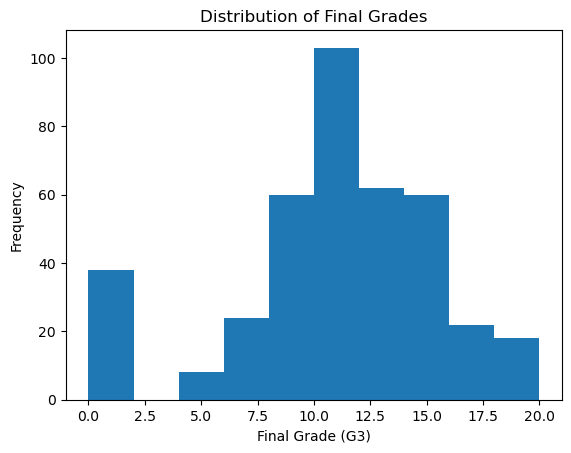

In [36]:
#Distribution of G3(Target Understanding)
plt.figure()
plt.hist(df['G3'], bins=10)
plt.xlabel("Final Grade (G3)")
plt.ylabel("Frequency")
plt.title("Distribution of Final Grades")
plt.show()

# Correlation Heatmap

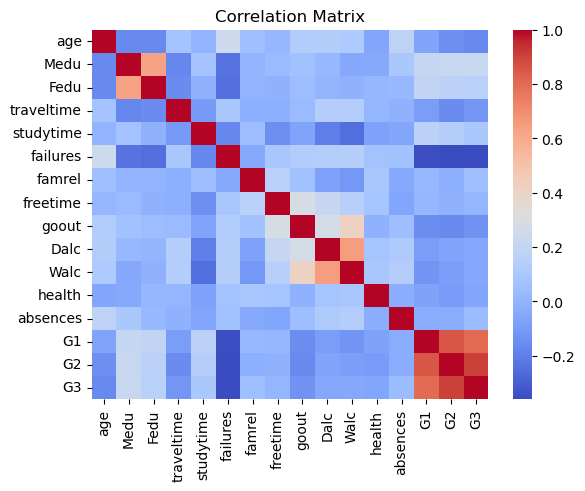

In [39]:
#Correlation Heatmap
import seaborn as sns

plt.figure()
sns.heatmap(df.select_dtypes(include=['number']).corr(), cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [7]:
#Creating a result column
"""
G1=First period grade
G2=Second period grade
G3=Final Grade
(Building a Classification model.)
instead of predicting exact marks(regression),we convert it into:
pass(1)
fail(0)"""

df['result']=df['G3'].apply(lambda x: 1 if x>=10 else 0)

"""For each student:
if G3>=10 -> result=1(pass)
if G3<10 -> result=0(fail)"""

'For each student:\nif G3>=10 -> result=1(pass)\nif G3<10 -> result=0(fail)'

# Data Preprocessing

In [8]:
#Encoding Categorical Data
df=pd.get_dummies(df,drop_first=True)

In [9]:
#Feature and Target Selection
#X=input
#y=output(what we need to predict)
X=df.drop(['G3','result'],axis=1)
y=df['result']

In [10]:
#Train-Test Split
#we split data:80% Training,20% Testing

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [11]:
#Building Model(Random Forest)
model=RandomForestClassifier()
model.fit(X_train,y_train)

RandomForestClassifier()

In [12]:
#Prediction
y_pred=model.predict(X_test)

In [13]:
#Accuracy Check
accuracy_score(y_test,y_pred)

0.9113924050632911

In [14]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test,y_pred))

[[25  2]
 [ 5 47]]


In [15]:
#Classification Report
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.83      0.93      0.88        27
           1       0.96      0.90      0.93        52

    accuracy                           0.91        79
   macro avg       0.90      0.91      0.90        79
weighted avg       0.92      0.91      0.91        79



In [16]:
X=df.drop(['G1','G2','G3','result'],axis=1)
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
model=RandomForestClassifier()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
print("Accuracy:",accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

Accuracy: 0.7215189873417721
[[ 8 19]
 [ 3 49]]


In [17]:
model=RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
print("Accuracy:",accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

Accuracy: 0.6962025316455697
[[ 7 20]
 [ 4 48]]


# Regression Model(Version 1: with G1 & G2)

In [18]:
#REGRESSION
#Prepare Data for Regression
y=df['G3']
X=df.drop(['G3'],axis=1)

In [19]:
#Train-Test Split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [20]:
#Using RandomForestRegressor
from sklearn.ensemble import RandomForestRegressor
model=RandomForestRegressor(
    n_estimators=200,max_depth=10,
    random_state=42
)
model.fit(X_train,y_train)

RandomForestRegressor(max_depth=10, n_estimators=200, random_state=42)

In [21]:
#Predictions
y_pred=model.predict(X_test)

In [22]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import numpy as np
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)
print("MAE:",mae)
print("RMSE:",rmse)
print("R2 Score:",r2)

MAE: 0.9861542521895944
RMSE: 1.7927213430908298
R2 Score: 0.8432654276794306


# Regression Model (Version 2: Clean Model)

In [29]:
X=df.drop(['G1','G2','G3','result'],axis=1)
y=df['G3']
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42
)
model=RandomForestRegressor(
    n_estimators=200,max_depth=10,
    random_state=42
)
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)
print("MAE:",mae)
print("RMSE:",rmse)
print("R2 Score:",r2)

MAE: 3.0796105779468017
RMSE: 3.863671689809004
R2 Score: 0.27198612461235583


# Actual vs Predicted Plot

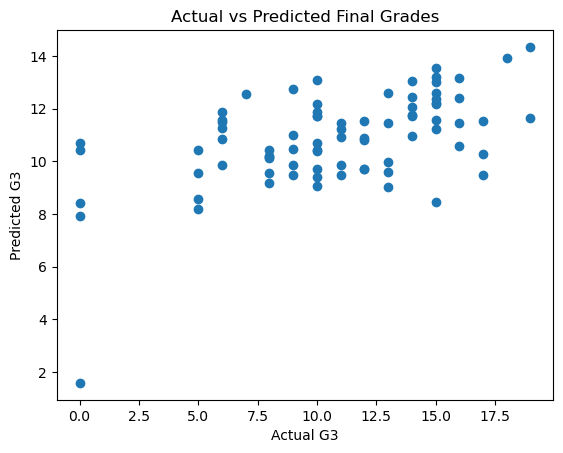

In [31]:
#Actual vs Predicted Plot
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual G3")
plt.ylabel("Predicted G3")
plt.title("Actual vs Predicted Final Grades")
plt.show()

# Residual Plot

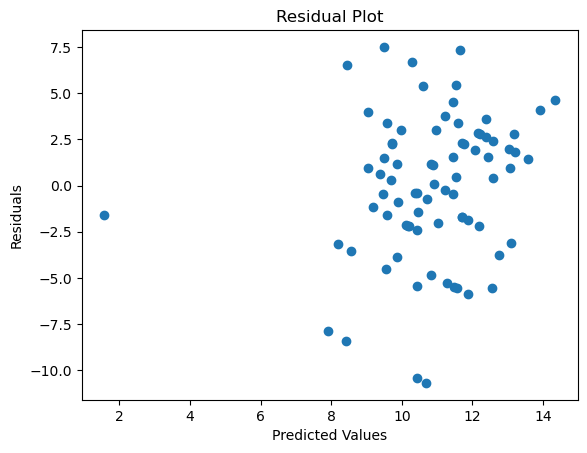

In [32]:
#Residual Plot(shows error pattern)
residuals = y_test - y_pred

plt.figure()
plt.scatter(y_pred, residuals)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

# 📊Feature Importance

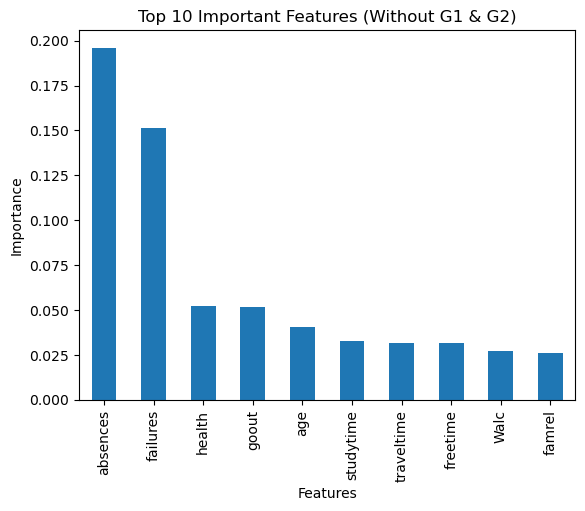

In [40]:
#Plot Feature Importance(Regression Version)
import matplotlib.pyplot as plt
import pandas as pd
feature_importance=pd.Series(model.feature_importances_,index=X.columns)
feature_importance=feature_importance.sort_values(ascending=False)
plt.figure()
feature_importance.head(10).plot(kind='bar')
plt.title("Top 10 Important Features (Without G1 & G2)")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

# Final Conclusion

## Conclusion
- Historical academic performance (G1,G2) strongly predicts final grade.
- Socio-behavioural features alone have limited predictive strength.
- Absences and prior failures are major influencing factors.
- Random forest proved effective for both classification and regression tasks.